XYLOFY AI Internship - Week 2


Task 1 - Data Loading and Exploration.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [6]:
de = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
de.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [7]:
print("Number of rows and columns : ",de.shape)

Number of rows and columns :  (1470, 35)


In [8]:
print("Target column: Attrition")
print("Attrition: ",de['Attrition'].unique())
print("Value counts: ",de['Attrition'].value_counts())

Target column: Attrition
Attrition:  ['Yes' 'No']
Value counts:  Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [9]:
print(de.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [10]:
print("Value counts: ",de['Attrition'].value_counts())
print("Employees left: ",de['Attrition'].value_counts().iloc[1])
print("Employees stayed: ",de['Attrition'].value_counts().iloc[0])

Value counts:  Attrition
No     1233
Yes     237
Name: count, dtype: int64
Employees left:  237
Employees stayed:  1233


In [11]:
arr = (de['Attrition'].value_counts().iloc[1]/len(de))*100
print(f"Attrition Rate: {arr:.2f}%")

Attrition Rate: 16.12%


In [12]:
categorical = de.select_dtypes(include=['object'])
print(categorical.columns)
print(f"Length of Categorical Columns: ",len(categorical.columns))
numerical = de.select_dtypes(include=['int64','float64'])
print(numerical.columns)
print(f"Length of Numerical Columns: ",len(numerical.columns))

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')
Length of Categorical Columns:  9
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')
Length of Numerical Columns:  26


Observation about Attrition Rate:

Here the attrition rate is 16.12 %, which means 16.12% of employees left.

Regarding the balance,
A dataset is considered to be balance only if both Yes and No have equal proportion ( 50% and 50% ). Here Yes has 16.12% and No has 83.88% . This shows that the dataset is clearly imbalanced. There is high imbalance in dataset - only 16.12% of employees left (237 out of 1470). So if not handled properly the model may be biased towards predicting 'No'.

Task 2 - Data Cleaning & Preprocessing


In [13]:
print(de.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

All columns show 0 missing values. Therefore the dataset is clearn and no need to handle it.


In [14]:
de = de.drop(columns = ['EmployeeCount','StandardHours','Over18','EmployeeNumber'])
print("Remaining columns: ",de.shape[1])

Remaining columns:  31


In [15]:
de['Attrition'] = de['Attrition'].map({'Yes':1,'No':0})
print(de['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [16]:
print(de.select_dtypes(include=['object']).columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [17]:
de = pd.get_dummies(de, columns = ['BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime'])
print(de.shape)

(1470, 52)


In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = de.select_dtypes(include = ['int64','float64']).columns.drop('Attrition')
de[numeric_cols] = scaler.fit_transform(de[numeric_cols])
print('Scaling is performed!')

Scaling is performed!


Task 3 - Exploratory Data Analysis

In [19]:
de_eda = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
dept_attr = de_eda.groupby('Department')['Attrition'].apply(lambda x:(x=='Yes').sum()/len(x)*100).round(2)
print(dept_attr)

Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
Name: Attrition, dtype: float64


So the findings from the output are:-

  -> Sales - 20.63% ( highest attrition )

  -> Human Resources - 19.05
  
  -> Research & Development - 13.84 ( lowest attrition )

We can find that sales department loses the most employees. 1 in 5 employess leave the company from sales department.

This makes sense, as sales role have high pressure, targets and are easy to switch between companies.

In [20]:
role_attr = de_eda.groupby('JobRole')['Attrition'].apply(lambda x:(x=='Yes').sum()/len(x)*100).round(2)
print(role_attr)

JobRole
Healthcare Representative     6.87
Human Resources              23.08
Laboratory Technician        23.94
Manager                       4.90
Manufacturing Director        6.90
Research Director             2.50
Research Scientist           16.10
Sales Executive              17.48
Sales Representative         39.76
Name: Attrition, dtype: float64


Sales Respresentative have the highest attrition rate of 39.76% - meaning almost 1 in 2 leave the company. Senior roles like Research Director and Manager have very low attrition. This shows that experience and seniority make employees more stable.

In [21]:
print(de_eda.groupby('Attrition')['MonthlyIncome'].mean().round(2))

Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


Average salary of employees who stayed:- Rs.6832.74

Average salary of employess who left:- Rs.4787.09

This shows that employees who left earned nearly Rs.2000 less per month on average compared to the employees who stayed. Lower paid employees are significantly more likely to leave - suggesting Salary is an important factor in attrition.

In [22]:
print(de_eda.groupby('WorkLifeBalance')['Attrition'].apply(lambda x:(x=='Yes').sum()/len(x) * 100).round(2))

WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


From the output we can find that, Employees with worst work life balance ( rating 1 ) leave at a rate of more than double of those with average work life balance ( rating 3 ).

Interestingly, rating 4 ( best ) has higher attrition rate than rating 3 ( better ) - possible because high performers with great balance gets better offer somewhere else.

In [23]:
print(de_eda.groupby('YearsAtCompany')['Attrition'].apply(lambda x:(x=='Yes').sum() / len(x) * 100).round(2))

YearsAtCompany
0      36.36
1      34.50
2      21.26
3      15.62
4      17.27
5      10.71
6      11.84
7      12.22
8      11.25
9       9.76
10     15.00
11      6.25
12      0.00
13      8.33
14     11.11
15      5.00
16      8.33
17     11.11
18      7.69
19      9.09
20      3.70
21      7.14
22      6.67
23     50.00
24     16.67
25      0.00
26      0.00
27      0.00
29      0.00
30      0.00
31     33.33
32     33.33
33     20.00
34      0.00
36      0.00
37      0.00
40    100.00
Name: Attrition, dtype: float64


From the output, we can find that Year 0 has 36.6% of attrition and Year 1 has 34.50% of attrition.This is very high - which means new joiners leave fast.

From year 5 onwards, attrition rate drops below 11% - which means employees become more stable.

Year 40 -> 100%. We can ignore this as there is only 1 employee.Not meaningful.

Year 23 -> 50%. We can ignore this also. Very few employess.

Attrition is highest in the first 2 years of employment. Nearly 1 in 3 new employees leave early. This suggest onboarding experience, early job staisfaction ahd initial salary play a huge role. Employees who cross 5 years are signficantly more likely to stay long term.

Business Insights from EDA:
1. Sales department has the highest attrition rate of 20.63% — 1 in 5 sales employees leave.
2. Sales Representatives have an alarming attrition rate of 39.76% — nearly 1 in 2 leave.
3. Employees who left earned ₹2000 less per month on average than those who stayed.
4. Employees with the worst work-life balance (rating 1) leave at 31.25% — double the average.
5. Attrition is highest in the first 2 years — 34-36% of new joiners leave early.

Task 4 - Model Building & Comparison


In [24]:
X = de.drop(columns = ['Attrition'])
y = de['Attrition']
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X shape:  (1470, 51)
y shape:  (1470,)


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size = 0.8, random_state = 3)
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)

X_train shape:  (1176, 51)
X_test shape:  (294, 51)


In [26]:
from sklearn.linear_model import LogisticRegression
lrm = LogisticRegression(class_weight = "balanced",random_state = 3)
lrm.fit(X_train,y_train)
print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [27]:
from sklearn.ensemble import RandomForestClassifier
rfm = RandomForestClassifier(class_weight = "balanced", random_state = 3)
rfm.fit(X_train,y_train)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [28]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state = 3)
gbc.fit(X_train,y_train)
print("Gradient Boosting Classifier trained successfully!")

Gradient Boosting Classifier trained successfully!


In [33]:
comparison11 = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Type': ['Single model', '100 trees in parallel', 'Trees in sequence'],
    'How it learns': ['Finds a formula/equation', 'Each tree votes, majority wins', "Each tree fixes previous tree's mistakes"],
    'Speed': ['Fast', 'Medium', 'Slow'],
    'Explainability': ['High - easy to explain to HR', 'Medium', 'Low - complex internal logic']
})
print(comparison11)

                 Model                   Type  \
0  Logistic Regression           Single model   
1        Random Forest  100 trees in parallel   
2    Gradient Boosting      Trees in sequence   

                              How it learns   Speed  \
0                  Finds a formula/equation    Fast   
1            Each tree votes, majority wins  Medium   
2  Each tree fixes previous tree's mistakes    Slow   

                 Explainability  
0  High - easy to explain to HR  
1                        Medium  
2  Low - complex internal logic  


Comparison Table of evaluation metrics of each model will be put up after getting to know the evaluation metrics. Kindly check in Task 5 for Comparison Table with evaluation metrics.

Task 5 - Model Evaluation

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
y_pred = lrm.predict(X_test)
print("Logistic Regression results: ")
print(classification_report(y_test,y_pred))
print("ROC-AUC Score: ",roc_auc_score(y_test,y_pred).round(2))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))

Logistic Regression results: 
              precision    recall  f1-score   support

           0       0.96      0.75      0.84       253
           1       0.35      0.83      0.49        41

    accuracy                           0.76       294
   macro avg       0.66      0.79      0.67       294
weighted avg       0.88      0.76      0.80       294

ROC-AUC Score:  0.79
Confusion Matrix: 
 [[190  63]
 [  7  34]]


Insight:- Recall is good (83%) - meaning the model catches most of the employees who will leave. Precision is low (35%) - meaning the model also raises many false alarms

In [30]:
y_pred_ranf = rfm.predict(X_test)
print("Random Forest results: ")
print(classification_report(y_test,y_pred_ranf))
print("ROC-AUC Score: ",roc_auc_score(y_test,y_pred_ranf).round(2))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred_ranf))

Random Forest results: 
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       253
           1       1.00      0.10      0.18        41

    accuracy                           0.87       294
   macro avg       0.94      0.55      0.55       294
weighted avg       0.89      0.87      0.83       294

ROC-AUC Score:  0.55
Confusion Matrix: 
 [[253   0]
 [ 37   4]]


Insight:- Random Forest looks good on Accuracy ( 87% ) but it's the imbalance problem - it's just predicting "will stay" for almost everyone! It missed 37 out of 41 leaving employees which is terrible for HR!

In [31]:
y_pred_gbc = gbc.predict(X_test)
print("Gradient Boosting Classifier Results: ")
print(classification_report(y_test,y_pred_gbc))
print("ROC-AUC score: ",roc_auc_score(y_test,y_pred_gbc).round(2))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred_gbc))

Gradient Boosting Classifier Results: 
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       253
           1       0.71      0.24      0.36        41

    accuracy                           0.88       294
   macro avg       0.80      0.61      0.65       294
weighted avg       0.86      0.88      0.85       294

ROC-AUC score:  0.61
Confusion Matrix: 
 [[249   4]
 [ 31  10]]


Gradient Boosting has the highest accuracy ( 88 % ) but its Recall for "will leave" is only 24% - which means it missed 31 out of 41 leaving employees. Despite high precision ( 71 % ), it is not useful for HR as catching leaving employees ( Recall ) matters more than accuracy here.

Comparison Table with Evaluation Metrics For Task 4:-

In [32]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [0.76, 0.87, 0.88],
    'Recall (Attrition)': [0.83, 0.10, 0.24],
    'Precision (Attrition)': [0.35, 1.00, 0.71],
    'F1 Score (Attrition)': [0.49, 0.18, 0.36],
    'ROC-AUC': [0.79, 0.55, 0.61]
})
print(comparison)

                 Model  Accuracy  Recall (Attrition)  Precision (Attrition)  \
0  Logistic Regression      0.76                0.83                   0.35   
1        Random Forest      0.87                0.10                   1.00   
2    Gradient Boosting      0.88                0.24                   0.71   

   F1 Score (Attrition)  ROC-AUC  
0                  0.49     0.79  
1                  0.18     0.55  
2                  0.36     0.61  


For HR attrition prediction, Recall is the most important metric because:

Missing an employee who is about to leave = costly (hiring + training costs)

So we rank models by Recall for class 1 (attrition) and ROC-AUC score:-

Logistic Regression wins on both the most important metrics:

Highest Recall (0.83) → catches most leaving employees.
Highest ROC-AUC (0.79) → best at separating leavers from stayers.

Therefore,

Best Model: Logistic Regression

Reason:
- Highest Recall (83%) — catches 34 out of 41 leaving employees
- Best ROC-AUC Score (0.79) — best at separating leavers from stayers
- Most explainable to HR teams

Although Random Forest and Gradient Boosting have higher accuracy,
they miss most leaving employees (Recall of 10% and 24%).
For HR, missing a leaving employee is more costly than a false alarm.
Therefore Logistic Regression is the best model for this problem.

In [35]:
import numpy as np

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(lrm.coef_[0])
})

feature_importance = feature_importance.sort_values('Importance', ascending=False)
print(feature_importance.head(10))

                              Feature  Importance
42          JobRole_Research Director    1.341524
45       JobRole_Sales Representative    1.096262
37  JobRole_Healthcare Representative    1.078192
49                        OverTime_No    0.876324
23          BusinessTravel_Non-Travel    0.861045
24   BusinessTravel_Travel_Frequently    0.785699
50                       OverTime_Yes    0.767045
34    EducationField_Technical Degree    0.732014
38            JobRole_Human Resources    0.731335
46             MaritalStatus_Divorced    0.673540


Feature Importance from Logistic Regression (Best Model):

The 3 factors that matter most in predicting attrition are:
1. Job Role — Research Director, Sales Representative, and Healthcare
   Representative are the strongest predictors.
2. OverTime — whether an employee works overtime or not strongly
   influences their likelihood of leaving.
3. Business Travel — how frequently an employee travels for work
   is a strong predictor of attrition.

In [39]:
print(f"{'Rank':<6} {'Feature':<40} {'Importance':<10}")
print("-" * 60)
for rank, (_, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    print(f"{rank:<6} {row['Feature']:<40} {row['Importance']:.2f}")

Rank   Feature                                  Importance
------------------------------------------------------------
1      JobRole_Research Director                1.34
2      JobRole_Sales Representative             1.10
3      JobRole_Healthcare Representative        1.08
4      OverTime_No                              0.88
5      BusinessTravel_Non-Travel                0.86
6      BusinessTravel_Travel_Frequently         0.79
7      OverTime_Yes                             0.77
8      EducationField_Technical Degree          0.73
9      JobRole_Human Resources                  0.73
10     MaritalStatus_Divorced                   0.67


Task 6 - Visualization ( Minimum 4 charts )

Chart 1: Bar chart showing attrition rate by Department and Job Role.


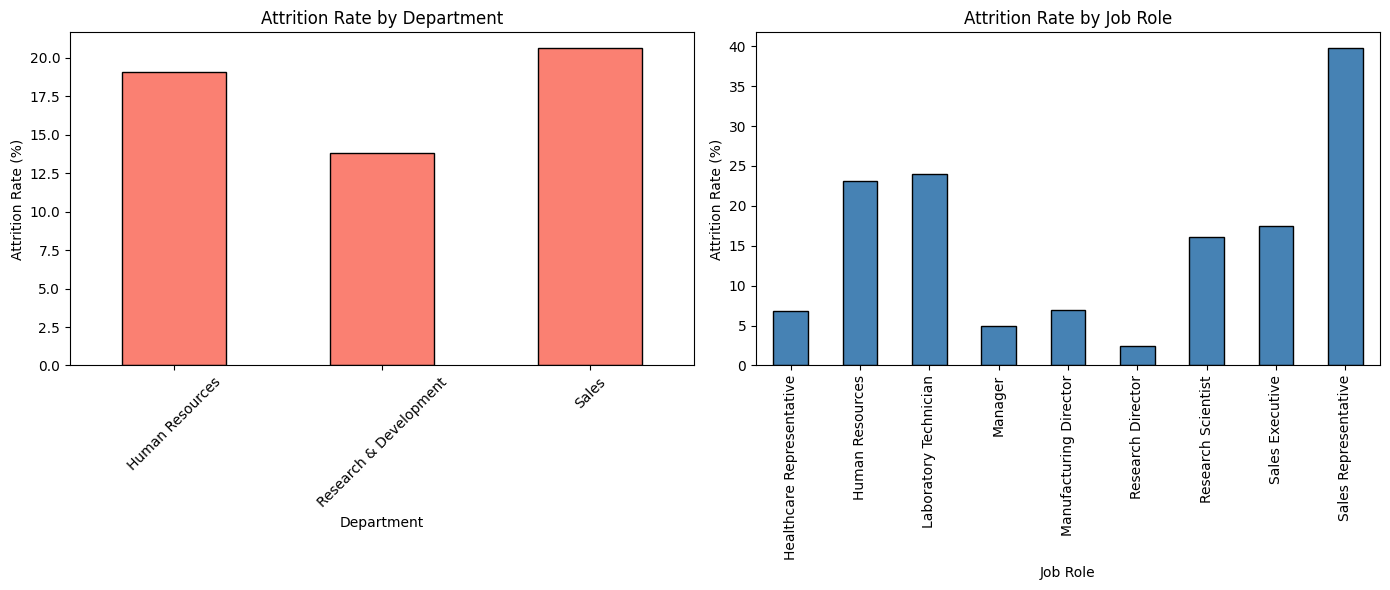

Chart 1 saved!


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

dept_attr.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

role_attr.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Attrition Rate by Job Role')
axes[1].set_xlabel('Job Role')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('chart1_attrition_by_dept_and_role.png')
plt.show()
print("Chart 1 saved!")

Chart 2: Box plot comparing Monthly Income of employees who left vs stayed.

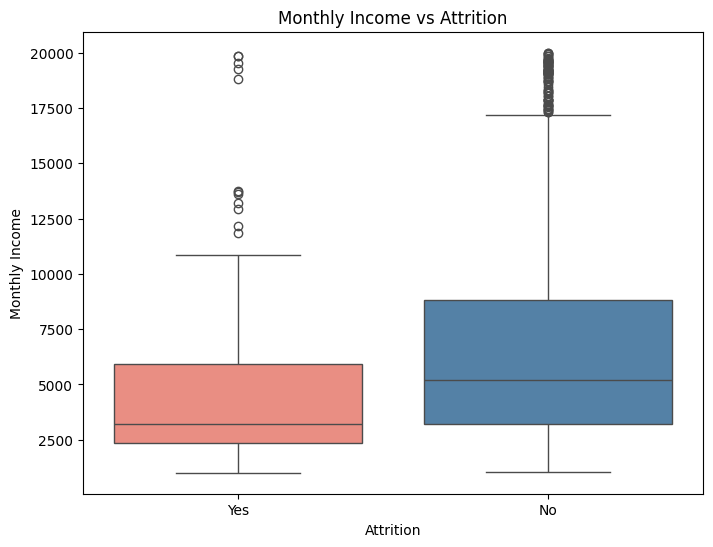

Chart 2 saved!


In [42]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=de_eda, hue='Attrition', palette={'Yes': 'salmon', 'No': 'steelblue'}, legend=False)
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.savefig('chart2_monthly_income_vs_attrition.png')
plt.show()
print("Chart 2 saved!")

Chart 3: Confusion Matrix heatmap for Logistic Regression.

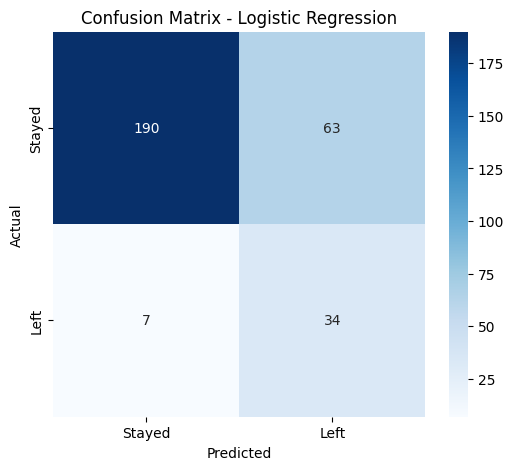

Chart 3 saved!


In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('chart3_confusion_matrix.png')
plt.show()
print("Chart 3 saved!")

Chart 4: Horizontal bar chart of Top 10 Feature Importances from Logistic Regression.

<Figure size 1000x600 with 0 Axes>

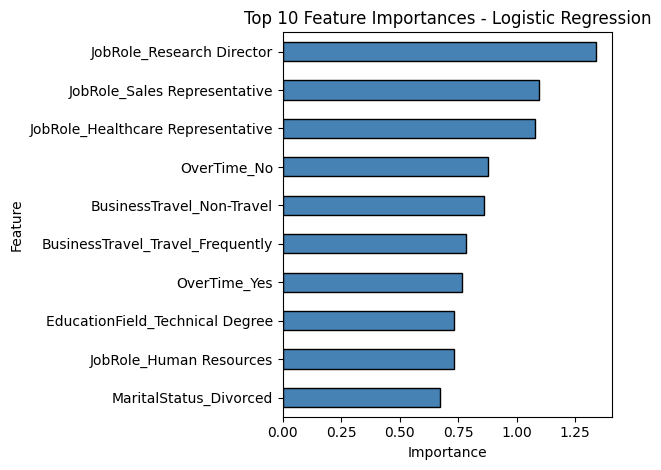

Chart 4 saved!


In [45]:
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='barh', x='Feature', y='Importance',
                                  color='steelblue', edgecolor='black',
                                  legend=False)
plt.title('Top 10 Feature Importances - Logistic Regression')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart4_feature_importance.png')
plt.show()
print("Chart 4 saved!")

Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph.

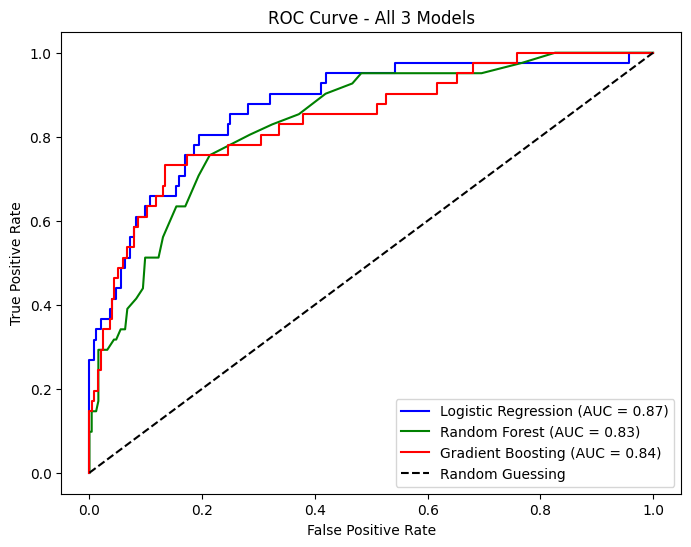

Chart 5 saved!


In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_probs = lrm.predict_proba(X_test)[:, 1]
rf_probs = rfm.predict_proba(X_test)[:, 1]
gb_probs = gbc.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})', color='blue')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})', color='green')
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, gb_probs):.2f})', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('ROC Curve - All 3 Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('chart5_roc_curve.png')
plt.show()
print("Chart 5 saved!")

Key observations:

Logistic Regression (AUC = 0.87) → highest curve, best model

Gradient Boosting (AUC = 0.84) → second best

Random Forest (AUC = 0.83) → third

All 3 models are well above the dashed line (random guessing)

Task 7 - HR Inisghts & Business Recommendations.

-> Which 3 factors most strongly predict that an employee will leave?
Answer:-  Top 3 Factors Predicting Attrition:
1. Job Role — Sales Representatives and Laboratory Technicians
   have the highest exit rates (39.76% and 23.94%).
2. OverTime — Employees working overtime are significantly
   more likely to leave.
3. Business Travel — Frequent travellers show higher attrition
   than non-travellers.



-> Which department or job role should HR prioritize for retention efforts?
Answer:- Department/Job Role to Prioritize:
- Sales department (20.63% attrition) and specifically
  Sales Representatives (39.76%) need immediate HR attention



-> Does salary alone explain attrition or are there other stronger factors?
Answer:-  No. While employees who left earned ₹2000 less on average,
  Job Role, OverTime and Business Travel are stronger predictors.
  Salary is important but not the only factor.



-> 2 concrete HR recommendations a company could implement based on our findings:-

HR Recommendations:
1. Introduce an OverTime policy — limit overtime hours and
   compensate employees fairly for extra hours worked.
   Target Sales and Lab Technician teams first.
2. Launch a retention program for Sales Representatives —
   structured career growth paths, salary reviews every
   6 months, and mentorship programs for employees in
   their first 2 years.



-> What limitation does this model have that an HR team should be aware of before using it?

Answer:-

Model Limitation:
- This model was trained on historical data and may not
  capture future changes in company culture, economy, or
  job market. Also, with only 237 attrition cases out of
  1470, the model has limited examples to learn from.
  HR should use this as a guide, not a final decision maker.



Internship Project Week-2 Completed.